## Project #1 Solutions

In [7]:
import pandas as pd

### Step 1: Student's clearly import data, change it to a dataframe and view the data to verify 
When grading: 
1. Consider whether the code is clean (has comments, natural breaks)
2. Compare to what was taught in lab and have the ACD open at the same time to determine whether AI may have been used to generate the code
3. Make sure the raw data file provided by the student runs in this code
4. Check that the student has used `print` or `.columns` or `.head()` or `.tail()` to view their data

In [8]:
## Load data
air_data = pd.read_csv('AirQuality_Daily_StudentVersion.csv')

## Turn data into a dataframe
air_data = pd.DataFrame(air_data)

## View data
air_data.head(5)

,date,monitor_index,humidity,pressure,temperature,voc,analog_input,pm2.5_alt,pm1.0_atm,pm2.5_atm,pm10.0_atm,sensor.latitude,sensor.longitude,sensor.altitude,sensor.name
0,02/23/24,195089,14.377667,912.884333,62.266667,51.998667,0.051333,0.1000,0.000000,0.002500,0.039667,40.050922,-101.533570,3005,Swnphd-Benklemen
1,02/23/24,195365,12.223600,926.403000,71.193400,64.920800,0.000000,0.1800,0.004800,0.020000,0.176000,40.200330,-100.639885,2576,Swnphd-mccook
2,02/23/24,195541,20.095750,905.670750,61.008250,68.307000,0.020000,0.1625,0.004125,0.014812,0.063937,41.128284,-101.720220,3220,Swnphd-ogallala
3,02/24/24,195089,25.368000,911.708833,51.462458,91.176750,0.052667,0.4375,0.099542,0.170667,0.355208,40.050922,-101.533570,3005,Swnphd-Benklemen
4,02/24/24,195365,23.703083,925.282125,56.818208,107.863708,0.000000,0.4750,0.099208,0.231687,0.548583,40.200330,-100.639885,2576,Swnphd-mccook


### Step 2: Verify students have the code to complete the analysis of the Air Quality data
There are several data analysis steps that can happen in any order.  The steps are outlined below with possible solutions.  If the students try a solution that is different, that is okay, but it must be present in their ACD and their explanation must be correct and have a source.  The students are allowed to use AI, but they must be able to explain the code generated by the AI in their ACD and they must have a source in order to get full credit.

#### Analysis: Creating Categorical Variables for Humidity and Temperature

Students need to create a categorical variable for humidity and temperature using the client prompt.  They should do this using a function and then the `.apply()` function to make sure the function gets applied to the data frame.

In [9]:
### Sample Humidity function 
def assign_humidity(humidity):
    if humidity < 50:
        return 'Low'
    elif 50 <= humidity <=80:
        return 'High'
    else:
        return 'Very High'
    
air_data['humidity_level'] = air_data['humidity'].apply(assign_humidity)
#print(air_data)

### Sample temperature function
def assign_temperature(temperature):
    if temperature < 32:
        return 'Below Freezing'
    elif 32 <= temperature <= 50:
        return 'Cool'
    elif 51 <= temperature <= 70:
        return 'Warm'
    else:
        return 'Hot'
    
air_data['temperature_level'] = air_data['temperature'].apply(assign_temperature)
#print(air_data)


In [49]:
## Students need to determine whether the temperature or humidity has a noticeable impact on AQ values.
air_data_humidity = air_data.groupby('humidity_level')

##Humidity and VOCs
air_data_humidity_summary_voc = air_data_humidity.agg(max=('voc', 'max'),
                                                min=('voc', 'min'),
                                                mean=('voc', 'mean'),
                                                median=('voc', 'median'))
#air_data_humidity_summary_voc

##Humidity and PM 2.5

air_data_humidity_summary_pm2_5 = air_data_humidity.agg(max=('pm2.5_atm', 'max'),
                                                min=('pm2.5_atm', 'min'),
                                                mean=('pm2.5_atm', 'mean'),
                                                median=('pm2.5_atm', 'median'))
#air_data_humidity_summary_pm2_5

##Humidity and PM 10

air_data_humidity_summary_pm10 = air_data_humidity.agg(max=('pm10.0_atm', 'max'),
                                                min=('pm10.0_atm', 'min'),
                                                mean=('pm10.0_atm', 'mean'),
                                                median=('pm10.0_atm', 'median'))
air_data_humidity_summary_pm10

,max,min,mean,median
humidity_level,,,,
High,2672.387917,0.023250,82.561133,11.062667
Low,3206.779708,0.012583,77.880520,6.676271
Very High,3784.682542,0.178854,536.520850,11.872094


#### Analysis: Grouping by Sensor Name

Students need to show that the sensor name is used to group the data throughout the project.  This grouping needs to appear at least once in their final Project #1 code. Remember that a `.groupby()` output will not show up on the console, so you need to verify the syntax or verify subsequent data is grouped correctly.

In [26]:
air_data_grouped = air_data.groupby('sensor.name')

#### Analysis: Aggregating data with summary statistics

Students need to show they have used the `.agg()` function to generate the mean, median and max for this Project.  The `.groupby()` function should have come before this step, otherwise the aggregation is not grouping by sensor name.

In [12]:
### Aggregate the grouped data

### Make sure the students take the mean, median and max of the values of the columns.  
## Summary stats on PM 2.5
air_data_aggregated_pm2_5 = air_data_grouped.agg(max=('pm2.5_atm', 'max'),
                                                min=('pm2.5_atm', 'min'),
                                                mean=('pm2.5_atm', 'mean'),
                                                median=('pm2.5_atm', 'median'))
#print(air_data_aggregated_pm2_5)

## Summary stats on PM 10
air_data_aggregated_pm10 = air_data_grouped.agg(max=('pm10.0_atm', 'max'),
                                                min=('pm10.0_atm', 'min'),
                                                mean=('pm10.0_atm', 'mean'),
                                                median=('pm10.0_atm', 'median'))
#print(air_data_aggregated_pm10)

## Summary stats on VOCs
air_data_aggregated_vocs = air_data_grouped.agg(max=('voc', 'max'),
                                                min=('voc', 'min'),
                                                mean=('voc', 'mean'),
                                                median=('voc', 'median'))
#print(air_data_aggregated_vocs)

In [48]:
### Find the top 5 locations with highest mean and median values of each parameter

### PM 2.5 Mean
top5_mean_pm2_5 = (
    air_data_aggregated_pm2_5
    .sort_values(by='mean', ascending=False)
    .head(5))
top5_mean_pm2_5

## PM 2.5 Median
top5_median_pm2_5 = (
    air_data_aggregated_pm2_5
    .sort_values(by='median', ascending=False)
    .head(5))
top5_median_pm2_5

## Here is a link to how this code was generated: https://chatgpt.com/share/695e9143-2c74-8000-bed2-06b976fb8e95 
## Teachable moment on how to use AI to help you generate clear code

,max,min,mean,median
sensor.name,,,,
Broken Bow,3205.868854,0.019187,928.710593,36.050240
#16 - Richardson County Courthouse,3782.823313,0.243729,700.127342,11.977344
#18 - Southeast District Health Department- Tecumseh,2987.467563,0.140708,613.175352,10.322875
ELVPHD Norfolk HD 4,79.972917,0.307896,13.369492,9.706229
ELVPHD Wisner HD 5,51.984812,0.154271,11.154420,8.464583


#### Analysis: Filtering for PM 2.5 and PM 10 values above AQI limits
Students need to look up the AQI limits for PM 2.5 and PM 10 and use these as filters to find locations with AQI concerns.  

PM 2.5 is Unhealthy for Sensitive groups at > 35.5
PM 10.0 is Unhealthy for Sensitive groups at > 155

In [46]:
##3Clean up data formatting
air_data = pd.DataFrame(air_data)
air_data['pm2.5_atm'] = pd.to_numeric(
    air_data['pm2.5_atm'], errors='coerce'
)

### Apply filters
unhealthy2_5 = air_data[air_data['pm2.5_atm'] >= 35.5]
unhealthy10 = air_data[air_data['pm10.0_atm'] >= 155]

##Create a pivot table!
pivot_excel_style = pd.pivot_table(
    unhealthy2_5,
    index='sensor.name',
    values='pm2.5_atm',
    aggfunc=['count', 'mean', 'max']
).round(2)

pivot_excel_style


,count,mean,max
,pm2.5_atm,pm2.5_atm,pm2.5_atm
sensor.name,,,
#16 - Richardson County Courthouse,107,2063.05,3782.82
#17 - Otoe County,2,36.50,37.25
#18 - Southeast District Health Department- Tecumseh,58,1918.05,2987.47
Ainsworth Public School #9,7,39.26,43.32
Broken Bow,187,1818.58,3205.87
Buffalo County TRPHD #26,7,39.16,42.23
ELVPHD Norfolk HD 4,7,46.08,79.97
ELVPHD Tekamah HD 3,2,41.87,45.88


### Analysis: What dates???
In this analysis, we're looking for students to have completed the analyses above and to be able to view specific lines of data so they can see which date is associated with which value.  This is more about viewing data that analyzing data, but is an important skill to check whether students are looking at and evaluating their data.

In [47]:
unhealthy_events = unhealthy2_5[
    ['date', 'sensor.name', 'pm2.5_atm']
].sort_values('date')

unhealthy_events.head(10)

,date,sensor.name,pm2.5_atm
6565,01/01/25,Broken Bow,2107.029354
6556,01/01/25,#16 - Richardson County Courthouse,2114.623250
6585,01/02/25,Broken Bow,1968.824813
6576,01/02/25,#16 - Richardson County Courthouse,2135.601729
6596,01/03/25,#16 - Richardson County Courthouse,2357.012438
6605,01/03/25,Broken Bow,2010.865833
6616,01/04/25,#16 - Richardson County Courthouse,2606.781167
6625,01/04/25,Broken Bow,2352.989979
6645,01/05/25,Broken Bow,2671.969104
6636,01/05/25,#16 - Richardson County Courthouse,3027.666146


#### BONUS Analysis:  Does sensor altitude have an impact on values?
This is advanced analysis.  This is a place to teach students how to use AI to generate and validate code.  

The idea here is to look at correlation.  Is altitude correlated to any of the NAAQS?  Let's start by looking at VOCs and altitude.  

ChatGPT was used on 1/8/26 with the Air Quality Dataset to help generate the following code.  It was adapted to what has already been generated in this notebook.

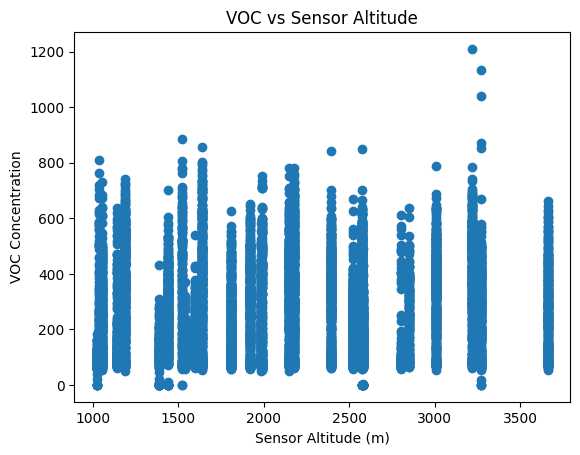

In [18]:
### Add additional functionality
#%pip install matplotlib
#%pip install scipy


import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


## We need only the VOC and altitude columns
air_data_correlation = air_data[["sensor.altitude", "voc"]]

##Handle missing values
data_clean = air_data_correlation.dropna()


### Create a visualization to get a feel for the correlation
plt.scatter(data_clean["sensor.altitude"], data_clean["voc"])
plt.xlabel("Sensor Altitude (m)")
plt.ylabel("VOC Concentration")
plt.title("VOC vs Sensor Altitude")
plt.show()


In [19]:
#### Use Pearson correlation to test for a linear relationship
r_pearson, p_pearson = pearsonr(
    data_clean["sensor.altitude"],
    data_clean["voc"]
)

print(f"Pearson correlation coefficient (r): {r_pearson:.3f}")
print(f"P-value: {p_pearson:.3e}")


Pearson correlation coefficient (r): 0.125
P-value: 6.671e-29


#### Explaining the output values
##### r value

+1 → strong positive relationship

0 → no linear relationship

−1 → strong negative relationship

##### p-value

Small p-value (< 0.05) → statistically significant

Large p-value → relationship may be due to random chance

In [20]:
### BONUS: Use Spearman correlation to check for monotonic relationships
r_spearman, p_spearman = spearmanr(
    data_clean["sensor.altitude"],
    data_clean["voc"]
)

print(f"Spearman correlation coefficient: {r_spearman:.3f}")
print(f"P-value: {p_spearman:.3e}")


Spearman correlation coefficient: 0.140
P-value: 2.626e-36
